# **Training Notebook**
### 🎯 **Gesture Recognition Application Using Feature Extraction - Assignment #1**

> Ilka BRETSCHNEIDER <br> Romain NOBLET


*Università degli Studi di Trento - 2026*

**Setup environment**

In [1]:
# Setup environment
!apt-get -qq install xxd
!pip install pandas numpy matplotlib
!pip install tensorflow

**Load data and normalization**

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

print(f"TensorFlow version = {tf.__version__}\n")

# Set a fixed random seed value, for reproducibility, this will allow us to get
# the same random numbers each time the notebook is run
SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED)

GESTURES = [
    "punch",
    "flex",
    "rightleft",
    "circle",
]

SAMPLES_PER_GESTURE = 119
NUM_GESTURES = len(GESTURES)
# create a one-hot encoded matrix that is used in the output
ONE_HOT_ENCODED_GESTURES = np.eye(NUM_GESTURES)

inputs = []
outputs = []

# Feature Functions

def rms(x):
    return np.sqrt(np.mean(np.square(x)))

def psd(x):
    fft_vals = np.fft.rfft(x)
    power = np.abs(fft_vals) ** 2
    return np.mean(power)

# Feature Extraction
for gesture_index in range(NUM_GESTURES):

    gesture = GESTURES[gesture_index]
    print(f"Processing index {gesture_index} for gesture '{gesture}'.")

    output = ONE_HOT_ENCODED_GESTURES[gesture_index]

    df = pd.read_csv("/content/" + gesture + ".csv")

    # calculate the number of gesture recordings in the file (20)
    num_recordings = int(df.shape[0] / SAMPLES_PER_GESTURE)

    print(f"\tThere are {num_recordings} recordings of the {gesture} gesture.")

    for i in range(num_recordings):

        ax, ay, az = [], [], []
        gx, gy, gz = [], [], []

        for j in range(SAMPLES_PER_GESTURE):
            index = i * SAMPLES_PER_GESTURE + j
            ax.append(df['aX'][index])
            ay.append(df['aY'][index])
            az.append(df['aZ'][index])
            gx.append(df['gX'][index])
            gy.append(df['gY'][index])
            gz.append(df['gZ'][index])

        signals = [
            np.array(ax), np.array(ay), np.array(az),
            np.array(gx), np.array(gy), np.array(gz)
        ]

        # compute raw features: shape (6 signals, 6 feature types)
        raw = np.array([
            [np.mean(s), np.std(s), rms(s), np.min(s), np.max(s), psd(s)]
            for s in signals
        ])

        # normalize
        col_min   = raw.min(axis=0)
        col_max   = raw.max(axis=0)
        col_range = col_max - col_min

        raw_normalized = (raw - col_min) / col_range

        tensor = raw_normalized.flatten()    # shape (36,)

        inputs.append(tensor)
        outputs.append(output)

# convert the list to numpy array
inputs = np.array(inputs)
outputs = np.array(outputs)

print("Data set parsing and preparation complete.")

TensorFlow version = 2.19.0

Processing index 0 for gesture 'punch'.
	There are 20 recordings of the punch gesture.
Processing index 1 for gesture 'flex'.
	There are 20 recordings of the flex gesture.
Processing index 2 for gesture 'rightleft'.
	There are 20 recordings of the rightleft gesture.
Processing index 3 for gesture 'circle'.
	There are 20 recordings of the circle gesture.
Data set parsing and preparation complete.


**Randomize and split the input and output pairs for training**

In [3]:
# Randomize the order of the inputs, so they can be evenly distributed for training, testing, and validation
# https://stackoverflow.com/a/37710486/2020087
num_inputs = len(inputs)
randomize = np.arange(num_inputs)
np.random.shuffle(randomize)

# Swap the consecutive indexes (0, 1, 2, etc) with the randomized indexes
inputs = inputs[randomize]
outputs = outputs[randomize]

# Split the recordings (group of samples) into three sets: training, testing and validation
TRAIN_SPLIT = int(0.6 * num_inputs)
TEST_SPLIT = int(0.2 * num_inputs + TRAIN_SPLIT)

inputs_train, inputs_test, inputs_validate = np.split(inputs, [TRAIN_SPLIT, TEST_SPLIT])
outputs_train, outputs_test, outputs_validate = np.split(outputs, [TRAIN_SPLIT, TEST_SPLIT])

print("Data set randomization and splitting complete.")

Data set randomization and splitting complete.


**Training a NN**

In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(inputs.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(NUM_GESTURES, activation='softmax')
])

model.compile(
    optimizer='adam',
    # loss function for classification tasks
    # (measure discrepancy between predicted probability distributions and actual)
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    inputs_train,
    outputs_train,
    epochs=200,
    batch_size=8,          # good balance of speed and stability
    validation_data=(inputs_validate, outputs_validate)
)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.2708 - loss: 1.3688 - val_accuracy: 0.2500 - val_loss: 1.2961
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4583 - loss: 1.2777 - val_accuracy: 0.7500 - val_loss: 1.2527
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9375 - loss: 1.2045 - val_accuracy: 0.9375 - val_loss: 1.2010
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9792 - loss: 1.1377 - val_accuracy: 0.9375 - val_loss: 1.1495
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9792 - loss: 1.0672 - val_accuracy: 0.9375 - val_loss: 1.0891
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9583 - loss: 0.9861 - val_accuracy: 0.9375 - val_loss: 1.0194
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9792 - loss: 0.8942 - val_accuracy: 0.9375 - val_loss: 0.9334
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9792 - loss: 0.7998 - val_accuracy: 0.8125 - val_loss:

**Model evaluation using accuracy and a confusion matrix**

In [5]:
test_loss, test_acc = model.evaluate(inputs_test, outputs_test)
print("Test accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 1.0000 - loss: 4.7257e-04
Test accuracy: 1.0


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


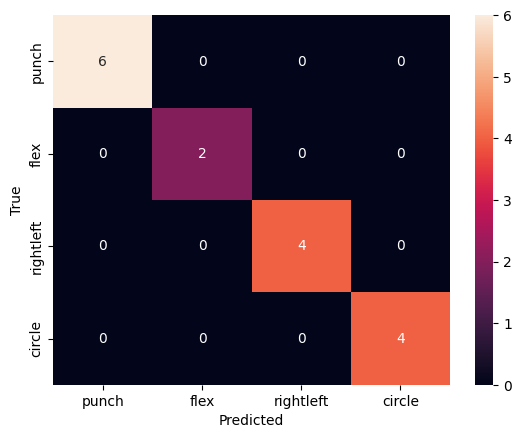

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = model.predict(inputs_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(outputs_test, axis=1)

cm = confusion_matrix(true_classes, predicted_classes)

sns.heatmap(cm, annot=True, fmt="d", xticklabels=GESTURES, yticklabels=GESTURES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

**The trained model parameters (weights and biases) are exported for deployment on Arduino.**

In [11]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("/content/gesture_model_quant.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpiec62is3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 36), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  136599516239184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136599516239760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136599516236880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136599516237072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136599516240336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136599516238608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136599516240720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136599516239568: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [12]:
!xxd -i /content/gesture_model_quant.tflite > /content/model.h

import os
model_h_size = os.path.getsize("model.h")
print(f"Header file, model.h, is {model_h_size:,} bytes.")
print("\nOpen the side panel (refresh if needed). Double click model.h to download the file.")

Header file, model.h, is 139,932 bytes.

Open the side panel (refresh if needed). Double click model.h to download the file.
